In [1]:
import os
import string
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from collections import Counter
import math

unfreeze_layers=24

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_seq_length=100):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, embed_size)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_size, 2).float() * 
                           (-math.log(10000.0) / embed_size))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class EncoderVGG16(nn.Module):
    def __init__(self, embed_size):
        super(EncoderVGG16, self).__init__()

        self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Geler TOUT l'encodeur d'abord
        for param in self.vgg.parameters():
            param.requires_grad_(False)
        
        # Dégeler uniquement le bloc 5 (layers 24-30)
        for layer in self.vgg.features[unfreeze_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Partie convolutionnelle
        self.vgg16_features = self.vgg.features

        # Projection des patches vers embed_size
        self.fc = nn.Linear(512, embed_size)

        # Normalisation et activation
        self.ln = nn.LayerNorm(embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        # Positional encoding visuel (49 patches = 7x7)
        self.visual_pos = nn.Parameter(torch.randn(1, 49, embed_size))

    def forward(self, images):
        with torch.no_grad():
            features = self.vgg16_features(images)          # [batch, 512, 7, 7]

        # Transformer les features en liste de patches
        features = features.flatten(2)                      # [batch, 512, 49]
        features = features.transpose(1, 2)                 # [batch, 49, 512]

        # Projection vers embed_size
        features = self.fc(features)                        # [batch, 49, embed_size]

        features = self.ln(features)
        features = self.relu(features)
        features = self.dropout(features)

        # Ajouter l'encodage de position visuel
        features = features + self.visual_pos               # [batch, 49, embed_size]

        return features


class DecoderTransformer(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads=8, num_layers=4,
                 ff_dim=1024, max_seq_length=100, dropout=0.3):
        super(DecoderTransformer, self).__init__()
        
        self.embed_size = embed_size
        self.max_seq_length = max_seq_length
        
        # Embeddings avec dropout plus élevé
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.positional_encoding = PositionalEncoding(embed_size, max_seq_length)
        
        # Transformer decoder layers avec dropout plus élevé
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers)
        
        # Output projection avec dropout
        self.output_projection = nn.Linear(embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.output_dropout = nn.Dropout(0.5)
        
    def generate_square_subsequent_mask(self, sz):
        """Génère un masque pour empêcher l'attention vers les tokens futurs"""
        mask = torch.triu(torch.ones(sz, sz)) == 1
        mask = mask.transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, image_features, captions):
        """
        image_features: [batch_size, 49, embed_size]
        captions: [batch_size, seq_len]
        """
        batch_size, seq_len = captions.shape
        
        # Word embeddings + positional encoding
        word_embeds = self.word_embedding(captions)
        word_embeds = word_embeds.transpose(0, 1)
        word_embeds = self.positional_encoding(word_embeds)
        word_embeds = word_embeds.transpose(0, 1)
        word_embeds = self.dropout(word_embeds)
        
        # Image features comme memory (contexte)
        image_memory = image_features
        
        # Masque causal pour empêcher de voir les tokens futurs
        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(captions.device)
        
        # Appliquer le transformer decoder
        output = self.transformer(
            tgt=word_embeds,
            memory=image_memory,
            tgt_mask=tgt_mask
        )
        
        # Projection finale vers le vocabulaire avec dropout
        output = self.output_dropout(output)
        output = self.output_projection(output)
        
        return output
    
    def sample(self, image_features, vocab, max_len=20, device='cpu'):
        """Génération autoregressive"""
        self.eval()
        batch_size = image_features.size(0)
        
        # Commencer avec le token <start>
        start_token = vocab['<start>']
        generated = torch.tensor([[start_token]], device=device)
        
        with torch.no_grad():
            for _ in range(max_len):
                # Forward pass
                output = self.forward(image_features, generated)
                
                # Prendre le dernier token prédit
                next_token_logits = output[:, -1, :]
                next_token = torch.argmax(next_token_logits, dim=-1)
                
                # Ajouter à la séquence générée
                generated = torch.cat([generated, next_token.unsqueeze(1)], dim=1)
                
                # Arrêter si on génère <end>
                if next_token.item() == vocab.get('<end>', -1):
                    break
        
        return generated[0].tolist()

In [3]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions, vocab, use_preprocessed=True):
        self.root_dir = root_dir
        self.captions = captions  # list of (image_name, caption)
        self.vocab = vocab
        self.use_preprocessed = use_preprocessed

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        img_name, caption = self.captions[idx]
        
        if self.use_preprocessed:
            # Charger le tensor préprocessé directement (.pt file)
            img_name_no_ext = img_name.split('.')[0]
            tensor_path = os.path.join(self.root_dir, f"{img_name_no_ext}.pt")
            image = torch.load(tensor_path)
        else:
            # Mode classique
            image = Image.open(os.path.join(self.root_dir, img_name)).convert("RGB")

        numerical_caption = [self.vocab["<start>"]] + \
            [self.vocab.get(word, self.vocab["<unk>"]) for word in caption.split()] + \
            [self.vocab["<end>"]]

        return image, torch.tensor(numerical_caption)


def build_vocab(captions_list, freq_threshold=5):
    counter = Counter()
    for _, caption in captions_list:
        counter.update(caption.split())

    words = [w for w, c in counter.items() if c >= freq_threshold]
    vocab = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
    for idx, word in enumerate(words, 4):
        vocab[word] = idx
    return vocab

In [5]:
import csv
import pandas as pd

if __name__ == "__main__":
    # === Load TRAIN captions file ===
    captions_list = []
    
    with open("outputs/train_captions.csv", "r", encoding="utf-8") as f:
        df = pd.read_csv(f, sep='|')
        for _, row in df.iterrows():
            img = row["image"].strip()
            caption = row["caption"].strip().lower()
            captions_list.append((img, caption))

    print(f"Train dataset: {len(captions_list)} captions")
    
    # === Load VAL captions file ===
    val_captions_list = []
    
    with open("outputs/val_captions.csv", "r", encoding="utf-8") as f:
        df_val = pd.read_csv(f, sep='|')
        for _, row in df_val.iterrows():
            img = row["image"].strip()
            caption = row["caption"].strip().lower()
            val_captions_list.append((img, caption))

    print(f"Validation dataset: {len(val_captions_list)} captions")
    
    # === Build vocabulary (seulement sur le train set) ===
    vocab = build_vocab(captions_list)
    vocab_size = len(vocab)
    print(f"Vocabulary size: {vocab_size}")

    # === Dataset & Dataloader pour TRAIN ===
    dataset = FlickrDataset(
        root_dir="outputs/train/",
        captions=captions_list,
        vocab=vocab,
        use_preprocessed=True
    )

    # === Dataset & Dataloader pour VAL ===
    val_dataset = FlickrDataset(
        root_dir="outputs/val/",
        captions=val_captions_list,
        vocab=vocab,
        use_preprocessed=True
    )

    def collate_fn(batch):
        images = torch.stack([img for img, _ in batch])
        captions = [cap for _, cap in batch]
        captions = torch.nn.utils.rnn.pad_sequence(captions, batch_first=True)
        return images, captions

    dataloader = DataLoader(dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
    val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, collate_fn=collate_fn)

    # === Device ===
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # === Models ===
    embed_size = 512
    num_heads = 8
    num_layers = 6
    ff_dim = 1024

    encoder = EncoderVGG16(embed_size).to(device)
    decoder = DecoderTransformer(
        embed_size=embed_size,
        vocab_size=vocab_size,
        num_heads=num_heads,
        num_layers=num_layers,
        ff_dim=ff_dim
    ).to(device)
    
    print(f"Transformer avec {num_layers} layers, {num_heads} heads, embed_size={embed_size}")

    # === Loss & Optimizer ===
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore <pad>
    
    # Séparer les paramètres VGG (bloc 5) des autres
    vgg_block5_params = []
    for layer in encoder.vgg.features[unfreeze_layers:]:
        vgg_block5_params.extend(layer.parameters())
    # Autres paramètres (decoder + encoder FC/LN/pos)
    other_params = (
    list(decoder.parameters()) + 
    list(encoder.fc.parameters()) + 
    list(encoder.ln.parameters()) + 
    [encoder.visual_pos]
    )
    # Optimizer avec learning rates différents
    optimizer = torch.optim.Adam([
        {'params': other_params, 'lr': 1e-4},           # Decoder + projection
        {'params': vgg_block5_params, 'lr': 1e-5}       # VGG bloc 5 (10x plus petit)
    ])



    # === Fonction d'évaluation ===
    def evaluate_model(encoder, decoder, val_dataloader, criterion, vocab_size, device):
        encoder.eval()
        decoder.eval()
        total_loss = 0
        num_batches = 0
        
        with torch.no_grad():
            for images, captions in val_dataloader:
                images, captions = images.to(device), captions.to(device)
                
                features = encoder(images)
                outputs = decoder(features, captions[:, :-1])
                targets = captions[:, 1:]
                
                loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
                total_loss += loss.item()
                num_batches += 1
        
        return total_loss / num_batches

    # === Training Loop avec validation ===
    num_epochs = 100
    
    print(f"\nDébut de l'entraînement pour {num_epochs} époques...")
    print("Epoch | Train Loss | Val Loss")
    print("-" * 35)

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []

    # for epoch in range(num_epochs):
    #     # === TRAINING ===
    #     decoder.train()
    #     encoder.train()  # On peut entraîner les couches FC
    #     total_train_loss = 0

    #     for images, captions in dataloader:
    #         images, captions = images.to(device), captions.to(device)

    #         optimizer.zero_grad()
            
    #         # Encoder: image -> features
    #         features = encoder(images)
            
    #         # Decoder: features + captions -> predictions
    #         outputs = decoder(features, captions[:, :-1])
    #         targets = captions[:, 1:]

    #         loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
    #         loss.backward()
            
    #         # Gradient clipping pour stabilité
    #         # Clip les paramètres de l'optimizer
    #         torch.nn.utils.clip_grad_norm_(other_params + vgg_block5_params, max_norm=1.0)
            
    #         optimizer.step()
    #         total_train_loss += loss.item()

    #     avg_train_loss = total_train_loss / len(dataloader)
    #     train_losses.append(avg_train_loss)
        
    #     # === VALIDATION ===
    #     avg_val_loss = evaluate_model(encoder, decoder, val_dataloader, criterion, vocab_size, device)
    #     val_losses.append(avg_val_loss)
        
    #     print(f"{epoch+1:5d} | {avg_train_loss:10.4f} | {avg_val_loss:8.4f}")
        
    #     # Sauvegarder le meilleur modèle
    #     if avg_val_loss < best_val_loss:
    #         best_val_loss = avg_val_loss
    #         torch.save({
    #             "encoder": encoder.state_dict(),
    #             "decoder": decoder.state_dict(),
    #             "vocab": vocab,
    #             "config": {
    #                 "embed_size": embed_size,
    #                 "num_heads": num_heads,
    #                 "num_layers": num_layers,
    #                 "ff_dim": ff_dim
    #             },
    #             "epoch": epoch + 1,
    #             "train_loss": avg_train_loss,
    #             "val_loss": avg_val_loss
    #         }, "best_ft_vgg_transformer_model.pth")
        
    #     # Early stopping si la validation loss ne s'améliore pas
    #     if epoch > 10 and avg_val_loss > min(val_losses[-5:]) * 1.1:
    #         print(f"Early stopping à l'époque {epoch+1}")
    #         break

    # # === Save Final Model ===
    # torch.save({
    #     "encoder": encoder.state_dict(),
    #     "decoder": decoder.state_dict(),
    #     "vocab": vocab,
    #     "config": {
    #         "embed_size": embed_size,
    #         "num_heads": num_heads,
    #         "num_layers": num_layers,
    #         "ff_dim": ff_dim
    #     },
    #     "train_losses": train_losses,
    #     "val_losses": val_losses
    # }, "caption_model_ft_vgg_transformer.pth")

    # print(f"\nTraining complete!")
    # print(f"Best validation loss: {best_val_loss:.4f}")
    # print(f"Final model saved as: caption_model_ft_vgg_transformer.pth")
    # print(f"Best model saved as: best_ft_vgg_transformer_model.pth")

Train dataset: 32360 captions
Validation dataset: 4045 captions
Vocabulary size: 2664
Using device: cuda:0
Transformer avec 6 layers, 8 heads, embed_size=512

Début de l'entraînement pour 100 époques...
Epoch | Train Loss | Val Loss
-----------------------------------


Testing transformer on 10 images from test set


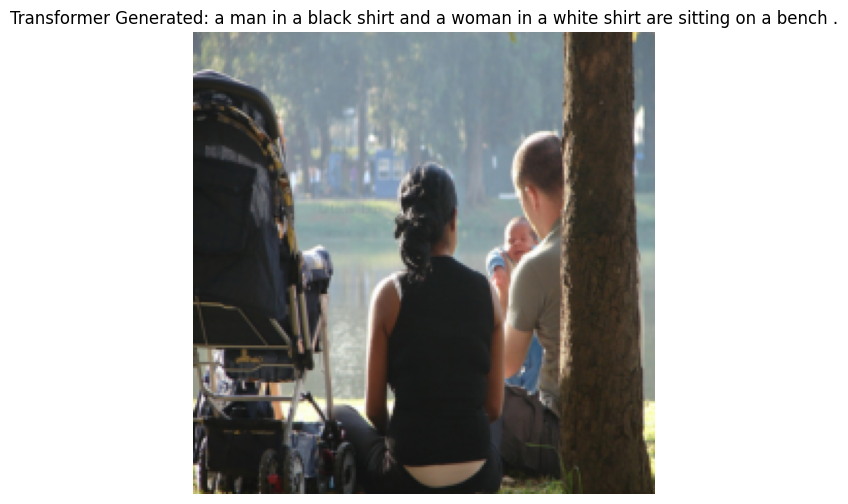

True captions for 1022454428_b6b660a67b.jpg:
  1. A couple and an infant , being held by the male , sitting next to a pond with a near by stroller .
  2. A couple sit on the grass with a baby and stroller .
  3. A couple with their newborn baby sitting under a tree facing a lake .
  4. A man and woman care for an infant along the side of a body of water .
  5. Couple with a baby sit outdoors next to their stroller .
--------------------------------------------------


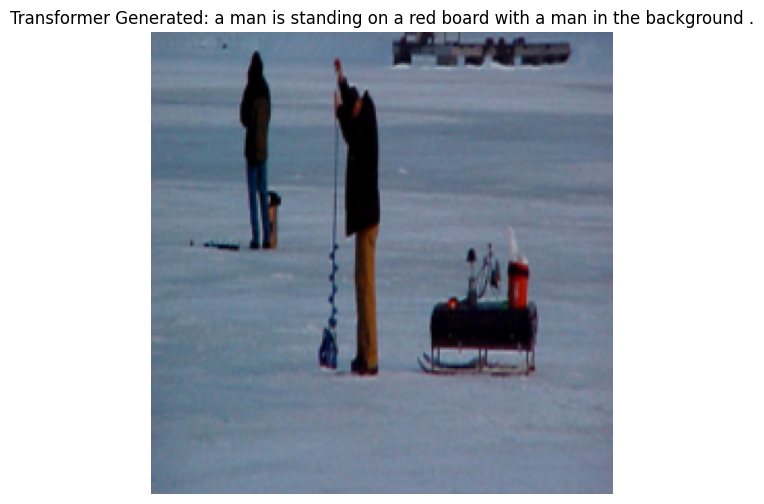

True captions for 102351840_323e3de834.jpg:
  1. A man drilling a hole in the ice .
  2. A man is drilling through the frozen ice of a pond .
  3. A person in the snow drilling a hole in the ice .
  4. A person standing on a frozen lake .
  5. Two men are ice fishing .
--------------------------------------------------


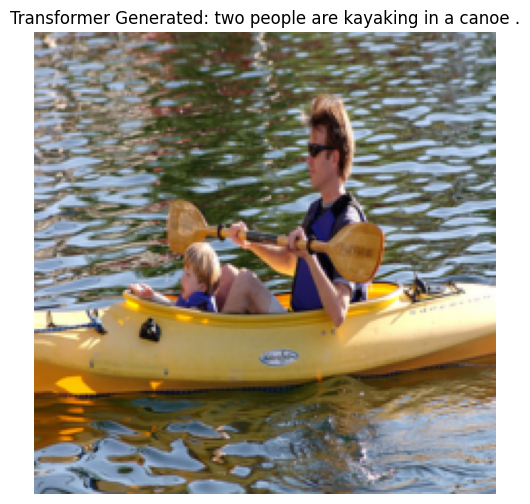

True captions for 1028205764_7e8df9a2ea.jpg:
  1. A man and a baby are in a yellow kayak on water .
  2. A man and a little boy in blue life jackets are rowing a yellow canoe .
  3. A man and child kayak through gentle waters .
  4. A man and young boy ride in a yellow kayak .
  5. Man and child in yellow kayak
--------------------------------------------------


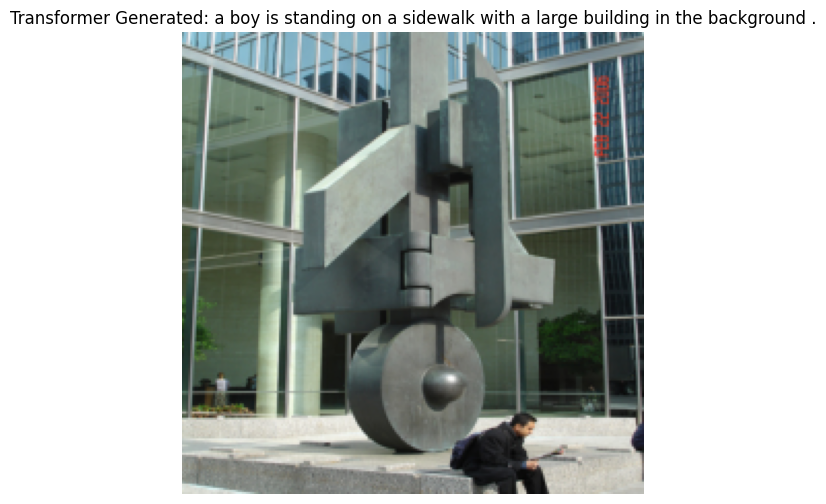

True captions for 103195344_5d2dc613a3.jpg:
  1. A man in black is sitting next to a modern art structure in front of a glass building .
  2. A man sits and reads a newspaper by a sculpture outside of an office building .
  3. a man sits near a large statue .
  4. A man sitting in front of a metal sculpture in front of a building .
  5. The man with the backpack is sitting in a buildings courtyard in front of an art sculpture reading .
--------------------------------------------------


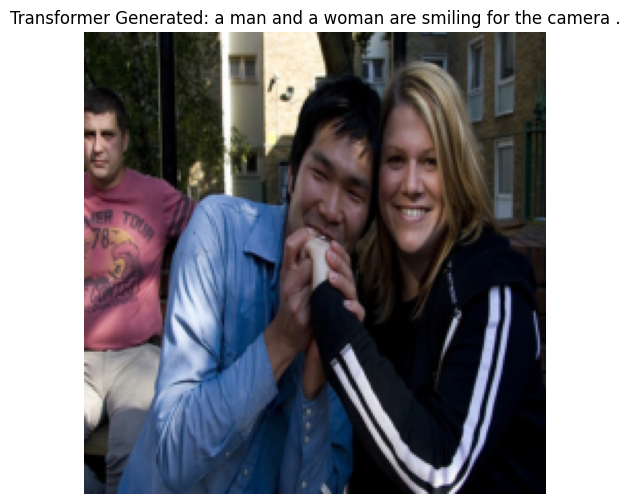

True captions for 1042590306_95dea0916c.jpg:
  1. A man and woman pose for the camera while another man looks on .
  2. A man is holding the hand of a woman up to his mouth in front of some buildings while another man looks on .
  3. A multiracial couple posing for a picture
  4. Asian man and blond woman holding hands outdoors , man in background watches .
  5. Guy in blue shirt biting hand of girl in black striped jacket while another guy watches
--------------------------------------------------


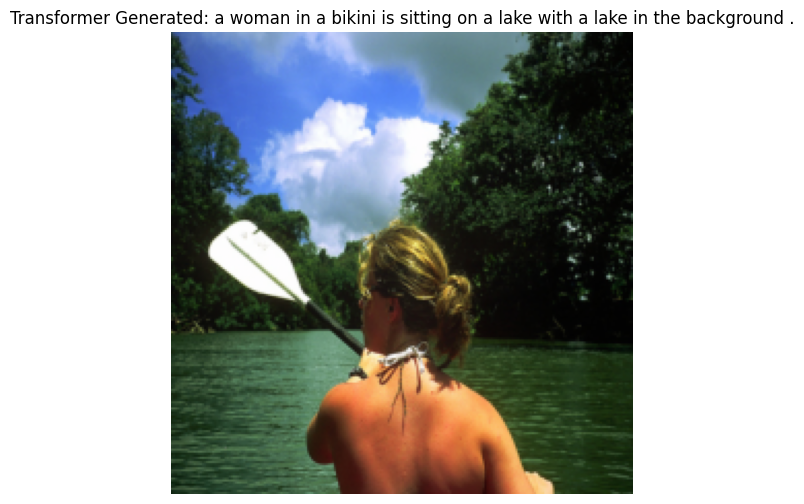

True captions for 105342180_4d4a40b47f.jpg:
  1. A girl paddling down a large river , as seen from behind her .
  2. A woman kayaking down a river .
  3. A woman paddles a boat down a river .
  4. A woman with a paddle .
  5. A woman with a paddle sits in a boat on the water .
--------------------------------------------------


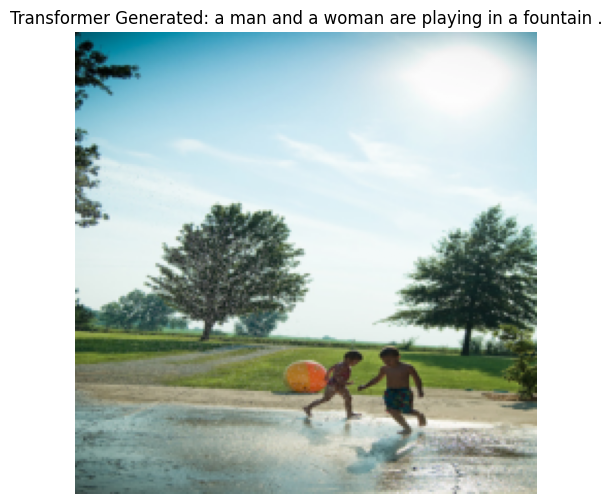

True captions for 1056249424_ef2a2e041c.jpg:
  1. The children are playing in the water .
  2. Two boys , one with a yellow and orange ball , play in some water in front of a field .
  3. Two boys play in a puddle .
  4. Two children play with a balloon in mud on a sunny day .
  5. Two kids are running and playing in some water .
--------------------------------------------------


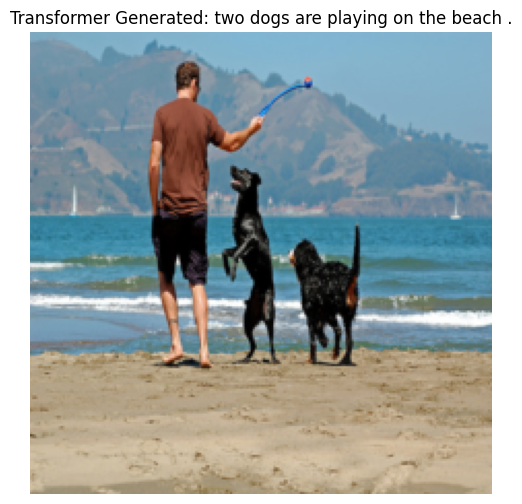

True captions for 1075867198_27ca2e7efe.jpg:
  1. A man in a brown shirt and dark shorts plays on the beach with his two black dogs .
  2. A man in shorts with two black dogs holds a ball throwing toy at the beach .
  3. a man playing with two black dogs on the beach
  4. A man with two dogs on a beach
  5. Man at the beach with two dogs .
--------------------------------------------------


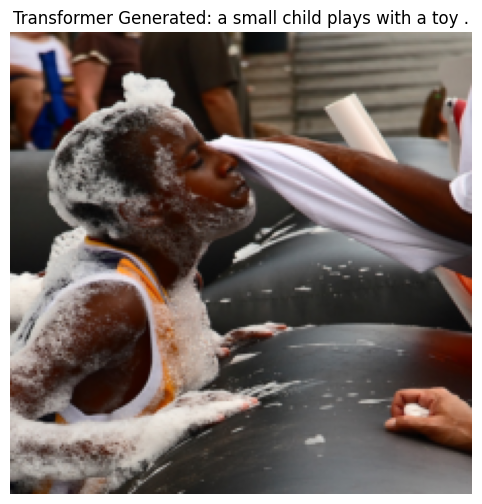

True captions for 1075881101_d55c46bece.jpg:
  1. a boy cleans the bubbles off his face .
  2. A boy covered in suds has his face wiped clean .
  3. A boy is covered in bubbles .
  4. A child covered in foam is climbing on a black inflatable ramp .
  5. A person covered in soapy water is getting cleaned off .
--------------------------------------------------


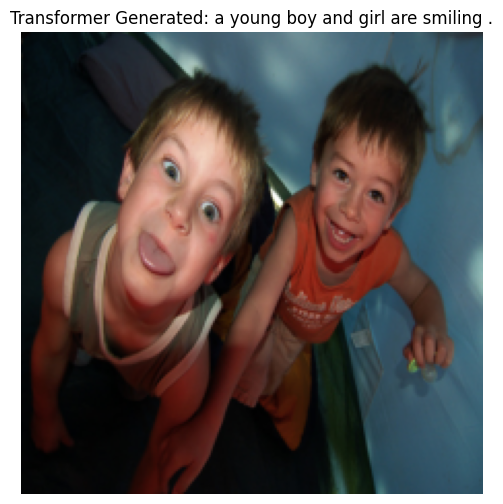

True captions for 1079274291_9aaf896cc1.jpg:
  1. A little boy sticks his tongue out for the camera . Another boy looks on .
  2. Two boys make faces .
  3. Two young boys are looking at the camera , one smiling , the other sticking his tongue out .
  4. Two young boys look up at the camera as one sticks out his tongue .
  5. two young boys making silly faces .
--------------------------------------------------


In [6]:
import torch
import pandas as pd
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image

# === Load checkpoint ===
checkpoint = torch.load("best_ft_vgg_transformer_model.pth", map_location=device)

# Recréer les modèles avec la même config
config = checkpoint["config"]
encoder = EncoderVGG16(config["embed_size"]).to(device)
decoder = DecoderTransformer(
    embed_size=config["embed_size"],
    vocab_size=len(checkpoint["vocab"]),
    num_heads=config["num_heads"],
    num_layers=config["num_layers"],
    ff_dim=config["ff_dim"]
).to(device)

encoder.load_state_dict(checkpoint["encoder"])
decoder.load_state_dict(checkpoint["decoder"])
vocab = checkpoint["vocab"]
idx2word = {idx: word for word, idx in vocab.items()}

encoder.eval()
decoder.eval()

# === Caption generation function ===
def generate_caption_transformer(image_tensor, encoder, decoder, vocab, idx2word, max_len=20):
    """Génère une caption avec le transformer"""
    with torch.no_grad():
        features = encoder(image_tensor.unsqueeze(0).to(device))
        output_ids = decoder.sample(features, vocab, max_len, device)
        
        # Convertir IDs en mots
        caption_words = []
        for idx in output_ids:
            word = idx2word.get(idx, "<unk>")
            if word == "<end>":
                break
            if word not in ["<start>", "<pad>"]:
                caption_words.append(word)
        
        return " ".join(caption_words)

def load_and_denormalize_image(tensor_path):
    """Charge un tensor préprocessé et le dénormalise pour affichage"""
    tensor = torch.load(tensor_path)
    
    # Dénormalisation
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    denorm_tensor = tensor * std + mean
    denorm_tensor = torch.clamp(denorm_tensor, 0, 1)
    
    denorm_array = denorm_tensor.permute(1, 2, 0).numpy()
    return tensor, denorm_array

# === Load TEST dataset images ===
test_df = pd.read_csv("outputs/test_captions.csv", sep='|')
test_images_list = test_df['image'].unique()[:10]

print(f"Testing transformer on {len(test_images_list)} images from test set")

# === Visualize test images ===
for img_name in test_images_list:
    img_name_no_ext = img_name.split('.')[0]
    tensor_path = f"outputs/test/{img_name_no_ext}.pt"
    
    # Charger le tensor et l'image dénormalisée
    image_tensor, display_image = load_and_denormalize_image(tensor_path)
    
    # Générer la caption avec transformer
    caption = generate_caption_transformer(image_tensor, encoder, decoder, vocab, idx2word)

    plt.figure(figsize=(8, 6))
    plt.imshow(display_image)
    plt.axis("off")
    plt.title(f"Transformer Generated: {caption}")
    plt.show()
    
    # Afficher les vraies captions
    true_captions = test_df[test_df['image'] == img_name]['caption'].tolist()
    print(f"True captions for {img_name}:")
    for i, true_cap in enumerate(true_captions, 1):
        print(f"  {i}. {true_cap}")
    print("-" * 50)

pour generer les captions sur test 

Génération des captions pour 811 images du test set
⚠️  Tensor non trouvé: outputs/test/image.pt


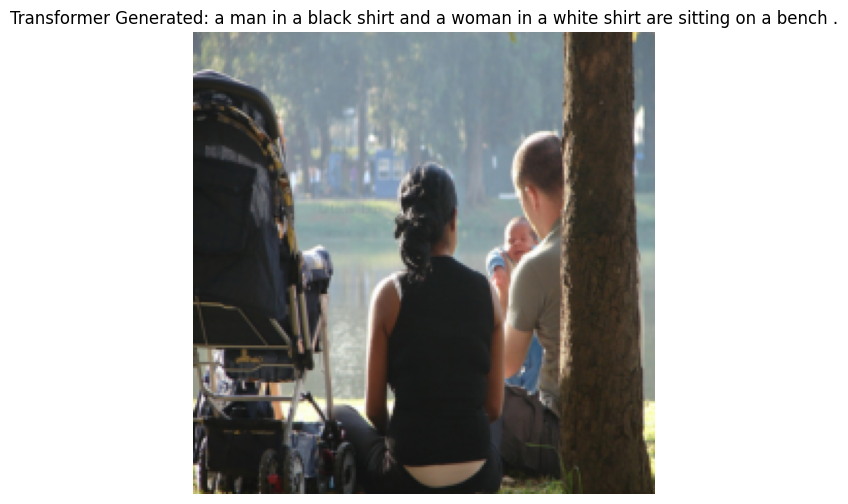

True captions for 1022454428_b6b660a67b.jpg:
  1. A couple and an infant , being held by the male , sitting next to a pond with a near by stroller .
  2. A couple sit on the grass with a baby and stroller .
  3. A couple with their newborn baby sitting under a tree facing a lake .
  4. A man and woman care for an infant along the side of a body of water .
  5. Couple with a baby sit outdoors next to their stroller .
--------------------------------------------------


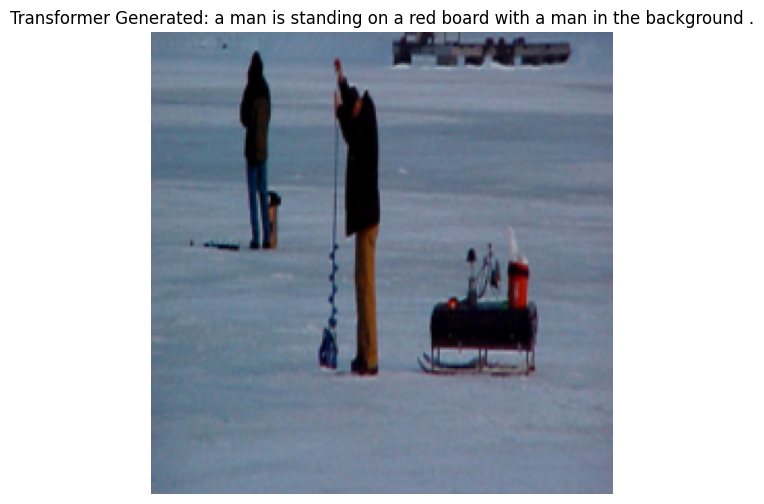

True captions for 102351840_323e3de834.jpg:
  1. A man drilling a hole in the ice .
  2. A man is drilling through the frozen ice of a pond .
  3. A person in the snow drilling a hole in the ice .
  4. A person standing on a frozen lake .
  5. Two men are ice fishing .
--------------------------------------------------


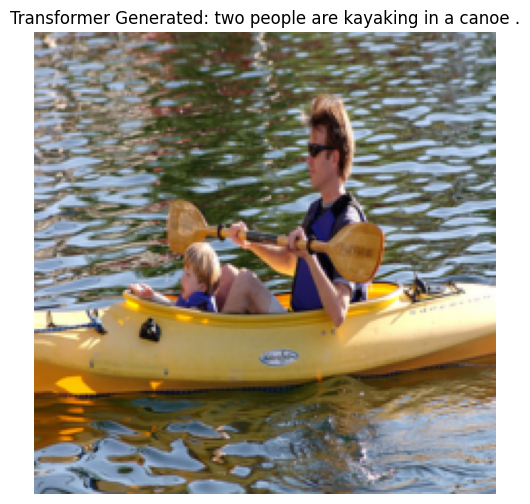

True captions for 1028205764_7e8df9a2ea.jpg:
  1. A man and a baby are in a yellow kayak on water .
  2. A man and a little boy in blue life jackets are rowing a yellow canoe .
  3. A man and child kayak through gentle waters .
  4. A man and young boy ride in a yellow kayak .
  5. Man and child in yellow kayak
--------------------------------------------------


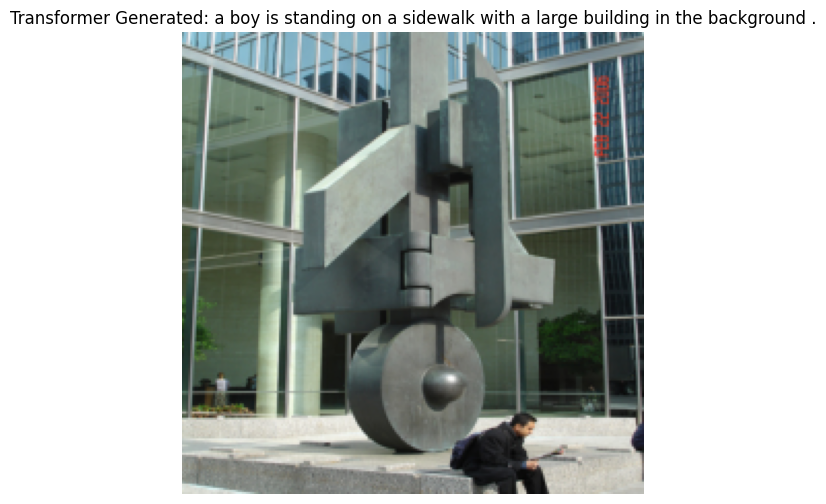

True captions for 103195344_5d2dc613a3.jpg:
  1. A man in black is sitting next to a modern art structure in front of a glass building .
  2. A man sits and reads a newspaper by a sculpture outside of an office building .
  3. a man sits near a large statue .
  4. A man sitting in front of a metal sculpture in front of a building .
  5. The man with the backpack is sitting in a buildings courtyard in front of an art sculpture reading .
--------------------------------------------------
Progression: 50/811 images traitées
Progression: 100/811 images traitées
Progression: 150/811 images traitées
Progression: 200/811 images traitées
Progression: 250/811 images traitées
Progression: 300/811 images traitées
Progression: 350/811 images traitées
Progression: 400/811 images traitées
Progression: 450/811 images traitées
Progression: 500/811 images traitées
Progression: 550/811 images traitées
Progression: 600/811 images traitées
Progression: 650/811 images traitées
Progression: 700/811 images t

In [7]:
import torch
import pandas as pd
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import os

# === Load checkpoint ===
checkpoint = torch.load("best_ft_vgg_transformer_model.pth", map_location=device)

# Recréer les modèles avec la même config
config = checkpoint["config"]
encoder = EncoderVGG16(config["embed_size"]).to(device)
decoder = DecoderTransformer(
    embed_size=config["embed_size"],
    vocab_size=len(checkpoint["vocab"]),
    num_heads=config["num_heads"],
    num_layers=config["num_layers"],
    ff_dim=config["ff_dim"]
).to(device)

encoder.load_state_dict(checkpoint["encoder"])
decoder.load_state_dict(checkpoint["decoder"])
vocab = checkpoint["vocab"]
idx2word = {idx: word for word, idx in vocab.items()}

encoder.eval()
decoder.eval()

# === Caption generation function ===
def generate_caption_transformer(image_tensor, encoder, decoder, vocab, idx2word, max_len=20):
    """Génère une caption avec le transformer"""
    with torch.no_grad():
        features = encoder(image_tensor.unsqueeze(0).to(device))
        output_ids = decoder.sample(features, vocab, max_len, device)
        
        # Convertir IDs en mots
        caption_words = []
        for idx in output_ids:
            word = idx2word.get(idx, "<unk>")
            if word == "<end>":
                break
            if word not in ["<start>", "<pad>"]:
                caption_words.append(word)
        
        return " ".join(caption_words)

def load_and_denormalize_image(tensor_path):
    """Charge un tensor préprocessé et le dénormalise pour affichage"""
    tensor = torch.load(tensor_path)
    
    # Dénormalisation
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    denorm_tensor = tensor * std + mean
    denorm_tensor = torch.clamp(denorm_tensor, 0, 1)
    
    denorm_array = denorm_tensor.permute(1, 2, 0).numpy()
    return tensor, denorm_array

# === Load TEST dataset images ===
test_df = pd.read_csv("outputs/test_captions.csv", sep='|', names=['image', 'caption'])
test_images_list = test_df['image'].unique()  # TOUTES les images
print(f"Génération des captions pour {len(test_images_list)} images du test set")

# === Liste pour stocker les résultats ===
generated_captions = []

# === Chemin de sortie ===
output_csv = "outputs/generated_captions/generated_captions_ft_vgg_dense_transformer.csv"

# === Générer les captions pour toutes les images ===
for idx, img_name in enumerate(test_images_list, 1):
    img_name_no_ext = img_name.split('.')[0]
    tensor_path = f"outputs/test/{img_name_no_ext}.pt"
    
    if not os.path.exists(tensor_path):
        print(f"⚠️  Tensor non trouvé: {tensor_path}")
        continue
    
    try:
        # Charger le tensor
        image_tensor, display_image = load_and_denormalize_image(tensor_path)
        
        # Générer la caption avec transformer
        caption = generate_caption_transformer(image_tensor, encoder, decoder, vocab, idx2word)
        
        # Stocker le résultat
        generated_captions.append({
            'image': img_name,
            'caption': caption
        })
        
        # Afficher la progression
        if idx % 50 == 0:
            print(f"Progression: {idx}/{len(test_images_list)} images traitées")
        
        # Optionnel: Visualiser quelques exemples (premiers 5 seulement)
        if idx <= 5:
            plt.figure(figsize=(8, 6))
            plt.imshow(display_image)
            plt.axis("off")
            plt.title(f"Transformer Generated: {caption}")
            plt.show()
            
            # Afficher les vraies captions
            true_captions = test_df[test_df['image'] == img_name]['caption'].tolist()
            print(f"True captions for {img_name}:")
            for i, true_cap in enumerate(true_captions, 1):
                print(f"  {i}. {true_cap}")
            print("-" * 50)
    
    except Exception as e:
        print(f"❌ Erreur pour {img_name}: {e}")
        continue

# === Sauvegarder toutes les captions dans le CSV ===
print(f"\n💾 Sauvegarde de {len(generated_captions)} captions dans {output_csv}...")

with open(output_csv, 'w', encoding='utf-8') as f:
    for result in generated_captions:
        f.write(f"{result['image']}|{result['caption']}\n")

print("✅ Captions générées et sauvegardées!")

# === Afficher quelques exemples ===
print(f"\n📊 Exemples de captions générées:")
print("-" * 60)
for i, result in enumerate(generated_captions[:5]):
    print(f"{result['image']}: {result['caption']}")
print("-" * 60)
print(f"\n🎯 Fichier sauvegardé: {output_csv}")
print(f"📈 Nombre total de captions: {len(generated_captions)}")

In [ ]:
# # === Comparaison LSTM vs Transformer ===
# # Charger aussi le modèle LSTM pour comparer

# try:
#     # Charger le modèle LSTM
#     lstm_checkpoint = torch.load("caption_model_2.pth", map_location=device)
    
#     # Recréer le decoder LSTM
#     class DecoderRNN(nn.Module):
#         def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
#             super(DecoderRNN, self).__init__()
#             self.embed = nn.Embedding(vocab_size, embed_size)
#             self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
#             self.linear = nn.Linear(hidden_size, vocab_size)
#             self.dropout = nn.Dropout(0.3)

#         def forward(self, features, captions):
#             embeddings = self.dropout(self.embed(captions[:, :-1]))
#             inputs = torch.cat((features.unsqueeze(1), embeddings), 1)
#             hiddens, _ = self.lstm(inputs)
#             outputs = self.linear(hiddens)
#             return outputs

#         def sample(self, features, max_len=20):
#             output_ids = []
#             states = None
#             inputs = features.unsqueeze(1)
#             for _ in range(max_len):
#                 hiddens, states = self.lstm(inputs, states)
#                 outputs = self.linear(hiddens.squeeze(1))
#                 predicted = outputs.argmax(1)
#                 output_ids.append(predicted.item())
#                 inputs = self.embed(predicted).unsqueeze(1)
#             return output_ids

#     # Créer les modèles LSTM
#     encoder_lstm = EncoderVGG16(256).to(device)
#     decoder_lstm = DecoderRNN(256, 512, len(lstm_checkpoint["vocab"])).to(device)
    
#     encoder_lstm.load_state_dict(lstm_checkpoint["encoder"])
#     decoder_lstm.load_state_dict(lstm_checkpoint["decoder"])
#     vocab_lstm = lstm_checkpoint["vocab"]
#     idx2word_lstm = {idx: word for word, idx in vocab_lstm.items()}
    
#     encoder_lstm.eval()
#     decoder_lstm.eval()
    
#     def generate_caption_lstm(image_tensor, encoder, decoder, idx2word, max_len=20):
#         with torch.no_grad():
#             features = encoder(image_tensor.unsqueeze(0).to(device))
#             output_ids = decoder.sample(features, max_len)
#             caption_words = []
#             for idx in output_ids:
#                 word = idx2word[idx]
#                 if word == "<end>":
#                     break
#                 if word != "<start>":
#                     caption_words.append(word)
#             return " ".join(caption_words)
    
#     print("Modèles LSTM et Transformer chargés avec succès!")
    
#     # === Comparaison sur quelques images ===
#     print("\n=== COMPARAISON LSTM vs TRANSFORMER ===")
    
#     for i, img_name in enumerate(test_images_list[:3]):
#         img_name_no_ext = img_name.split('.')[0]
#         tensor_path = f"outputs/test/{img_name_no_ext}.pt"
#         image_tensor, display_image = load_and_denormalize_image(tensor_path)
        
#         # Générer avec LSTM
#         caption_lstm = generate_caption_lstm(image_tensor, encoder_lstm, decoder_lstm, idx2word_lstm)
        
#         # Générer avec Transformer
#         caption_transformer = generate_caption_transformer(image_tensor, encoder, decoder, vocab, idx2word)
        
#         # Vraies captions
#         true_captions = test_df[test_df['image'] == img_name]['caption'].tolist()
        
#         print(f"\nImage {i+1}: {img_name}")
#         print(f"LSTM:        {caption_lstm}")
#         print(f"Transformer: {caption_transformer}")
#         print(f"True:        {true_captions[0]}")
#         print("-" * 70)

# except FileNotFoundError:
#     print("Modèle LSTM non trouvé. Entraînez d'abord le modèle LSTM dans test.ipynb")